# Defensive allocation: canaries govern exposure, rankings govern holdings

**Constructed educational scenarios; not a historical DAA replication.** Zero, one and two weak canaries produce 0%, 50% and 100% defense under this exercise's threshold of two. A fourth case shows that weak risky assets alone do not trigger this canary rule.

[Chapter narrative](README.md) · [Research collection](../../README.md)

## Goal

Distinguish three roles: investment candidates, canary signals and defensive holdings. Attribution: Keller and Keuning, [*Breadth Momentum and the Canary Universe: Defensive Asset Allocation* (2018)](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3212862). This chapter renews the original `07_defensive_asset_allocation_with_momentum_monthly.ipynb` topic with a transparent role-based exercise.

## Setup

Four fictional risky assets, two fictional canaries and two fictional defensive assets have twelve constructed monthly returns. The universes are disjoint here for clarity; overlap is possible in other designs. No constructed series is an actual ETF history.

The exercise uses a breadth threshold of two, two equally weighted risky holdings and one defensive holding. It does not reproduce all published portfolio-slot rounding conventions. Risky selection is relative: negative scores do not themselves force defense when the canaries are healthy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (10, 4.6), 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.18,
    'axes.axisbelow': True, 'figure.dpi': 120,
})
BLUE, GOLD, GRAY = '#245a81', '#bc8431', '#606975'
# All prices are constructed inside this notebook; there are no downloads.

In [2]:
risky = ['US equity', 'Global equity', 'REIT', 'Gold']
canaries = ['Emerging canary', 'Bond canary']
defensive = ['Bills', 'Treasury']
assets = risky + canaries + defensive
base_return = np.array([0.018, 0.014, 0.010, 0.006, 0.012, 0.004, 0.002, 0.003])
monthly_scenarios = {}
for name in ['All positive', 'One weak canary', 'Two weak canaries', 'Risk weak; canaries positive']:
    monthly_scenarios[name] = pd.DataFrame(np.tile(base_return, (12, 1)), columns=assets)
monthly_scenarios['One weak canary'].loc[11, 'Emerging canary'] = -0.06
monthly_scenarios['Two weak canaries'].loc[11, canaries] = [-0.06, -0.025]
monthly_scenarios['Risk weak; canaries positive'].loc[11, risky] = [-0.08, -0.07, -0.06, -0.04]

## Steps

### 1. Give every asset the same price-based measurement

Compute $12R_1+4R_3+2R_6+R_{12}$ from thirteen monthly prices. Keeping the measurement fixed makes the effect of the monitored universe interpretable.

In [3]:
def weighted_momentum(path, information_month=12):
    history = path.loc[:information_month]
    if len(history) < 13 or history.isna().any().any():
        raise ValueError('Need thirteen complete monthly price observations.')
    if not np.isfinite(history.to_numpy()).all() or (history <= 0).any().any():
        raise ValueError('Prices must be finite and positive.')
    current = history.iloc[-1]
    return sum(weight * (current / history.iloc[-1 - lag] - 1)
               for lag, weight in [(1, 12), (3, 4), (6, 2), (12, 1)])

def constructed_path(monthly_returns):
    monthly_returns = pd.DataFrame(monthly_returns)
    levels = np.vstack([np.ones(monthly_returns.shape[1]),
                        np.cumprod(1 + monthly_returns.to_numpy(), axis=0)])
    return pd.DataFrame(100 * levels, columns=monthly_returns.columns,
                        index=pd.Index(range(len(levels)), name='Constructed month'))

In [4]:
paths = {name: constructed_path(returns) for name, returns in monthly_scenarios.items()}
scores = pd.DataFrame({name: weighted_momentum(path) for name, path in paths.items()}).T
display(scores.round(3))

,US equity,Global equity,REIT,Gold,Emerging canary,Bond canary,Bills,Treasury
All positive,0.901,0.694,0.491,0.292,0.592,0.194,0.096,0.145
One weak canary,0.901,0.694,0.491,0.292,-0.802,0.194,0.096,0.145
Two weak canaries,0.901,0.694,0.491,0.292,-0.802,-0.361,0.096,0.145
Risk weak; canaries positive,-1.015,-0.938,-0.860,-0.590,0.592,0.194,0.096,0.145


### 2. Use the canaries to size exposure

The defensive fraction is $\min(1,b/2)$, where $b$ counts non-positive **canary** scores. Equally divide the remaining budget over the top two risky assets. Canary assets do not receive weights in this exercise because its sets are disjoint. Ties are resolved by name.

In [5]:
def daa_style_weights(score, breadth_threshold=2, number_risky=2):
    if breadth_threshold <= 0 or not 1 <= number_risky <= len(risky):
        raise ValueError('Invalid breadth or risky-holdings count.')
    weak_canaries = int((score.loc[canaries] <= 0).sum())
    defensive_fraction = min(1.0, weak_canaries / breadth_threshold)
    ranked_risky = score.loc[risky].sort_index().sort_values(ascending=False, kind='stable')
    chosen = ranked_risky.head(number_risky).index
    chosen_defensive = score.loc[defensive].sort_index().sort_values(ascending=False, kind='stable').index[0]
    target = pd.Series(0.0, index=assets)
    target.loc[chosen] = (1 - defensive_fraction) / number_risky
    target.loc[chosen_defensive] = defensive_fraction
    return target

targets = pd.DataFrame({name: daa_style_weights(row) for name, row in scores.iterrows()}).T
decisions = pd.DataFrame({
    'Weak risky assets': (scores[risky] <= 0).sum(axis=1),
    'Weak canaries': (scores[canaries] <= 0).sum(axis=1),
    'DAA-style defensive weight': targets[defensive].sum(axis=1),
    'VAA-style weight with same B=2': ((scores[risky] <= 0).sum(axis=1) / 2).clip(upper=1),
})
display(decisions)
display(targets.loc[:, (targets != 0).any()].style.format('{:.0%}'))

,Weak risky assets,Weak canaries,DAA-style defensive weight,VAA-style weight with same B=2
All positive,0,0,0.0,0.0
One weak canary,0,1,0.5,0.0
Two weak canaries,0,2,1.0,0.0
Risk weak; canaries positive,4,0,0.0,1.0


,US equity,Global equity,REIT,Gold,Treasury
All positive,50%,50%,0%,0%,0%
One weak canary,25%,25%,0%,0%,50%
Two weak canaries,0%,0%,0%,0%,100%
Risk weak; canaries positive,0%,0%,50%,50%,0%


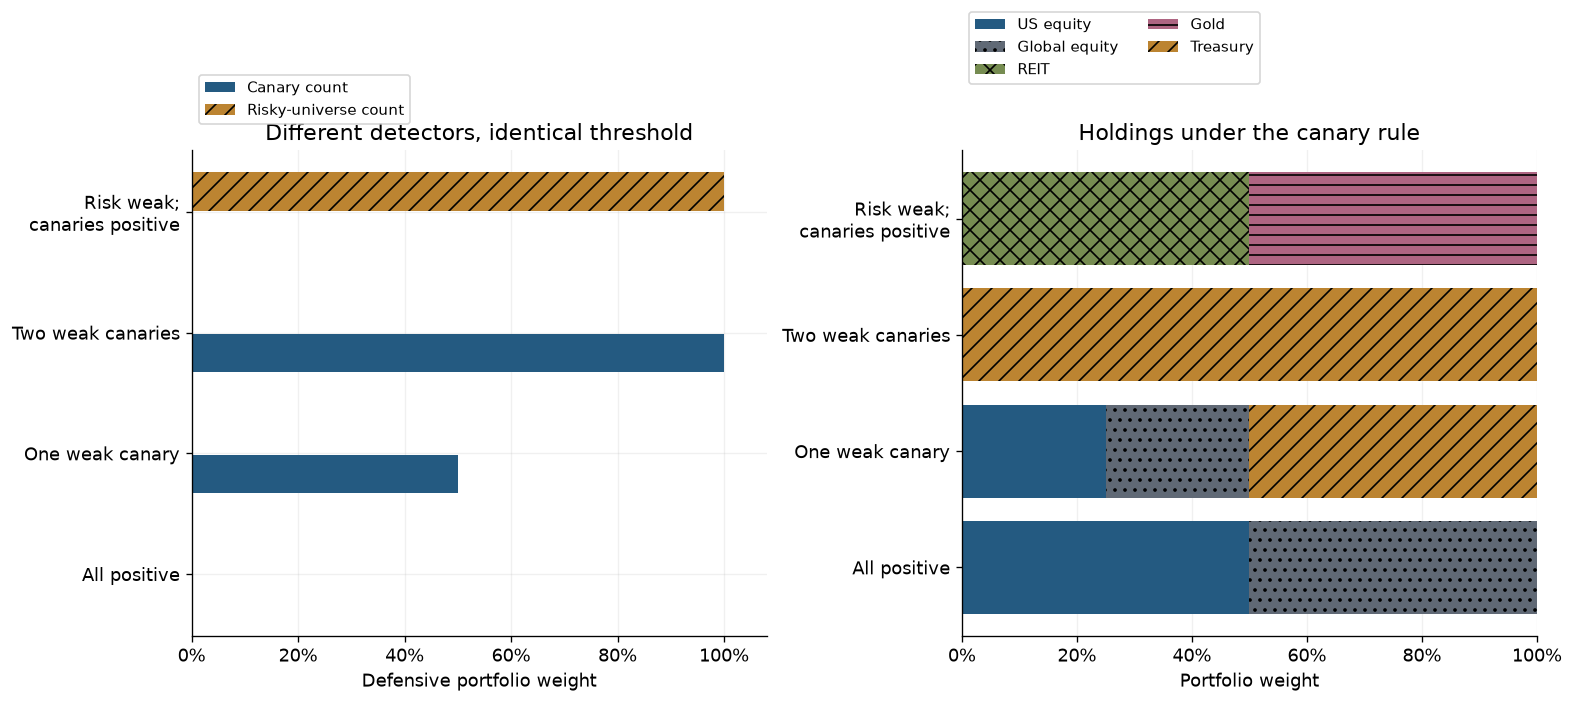

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.7), layout='constrained')
y = np.arange(len(decisions))
labels = ['All positive', 'One weak canary', 'Two weak canaries', 'Risk weak;\ncanaries positive']
axes[0].barh(y - 0.17, decisions['DAA-style defensive weight'], 0.32, color=BLUE, label='Canary count')
axes[0].barh(y + 0.17, decisions['VAA-style weight with same B=2'], 0.32,
            color=GOLD, hatch='//', label='Risky-universe count')
axes[0].set(yticks=y, yticklabels=labels, xlim=(0, 1.08),
            xlabel='Defensive portfolio weight', title='Different detectors, identical threshold')
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend(loc='upper left', bbox_to_anchor=(0, 1.17), fontsize=9)
left = np.zeros(len(targets))
for name, color, hatch in [('US equity', BLUE, ''), ('Global equity', GRAY, '..'),
                          ('REIT', '#768c51', 'xx'), ('Gold', '#ae6582', '--'),
                          ('Treasury', GOLD, '//')]:
    values = targets[name].to_numpy()
    axes[1].barh(y, values, left=left, color=color, label=name, hatch=hatch)
    left += values
axes[1].set(yticks=y, yticklabels=labels, xlim=(0, 1),
            xlabel='Portfolio weight', title='Holdings under the canary rule')
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend(loc='upper left', bbox_to_anchor=(0, 1.30), fontsize=9, ncol=2)
np.testing.assert_allclose(left, 1)
plt.show()

The one-canary case reduces the risky budget without changing risky rankings. In the last case, canaries remain healthy while risky momentum turns negative: the rule still invests in relative winners. This is a feature of the declared detector, not evidence that its signals are timely. The VAA-style comparison changes only which universe supplies the breadth count.

## Checks

Check the three exposure levels, canary/holding separation, an independent constant-growth score and signal invariance to future values. Information arrives at month 12, a hypothetical trade executes at month 13, and the first owned return ends at month 14. The notebook reports allocation decisions rather than hypothetical backtest performance.

In [7]:
np.testing.assert_allclose(decisions['DAA-style defensive weight'], [0, 0.5, 1, 0])
np.testing.assert_allclose(decisions['VAA-style weight with same B=2'], [0, 0, 0, 1])
np.testing.assert_allclose(targets.sum(axis=1), 1)
assert (targets >= 0).all().all() and (targets[canaries] == 0).all().all()
np.testing.assert_allclose(scores.loc['All positive', risky], scores.loc['One weak canary', risky])
np.testing.assert_allclose(targets.loc['One weak canary', risky], 0.5 * targets.loc['All positive', risky])
constant_growth = pd.DataFrame({'Known path': 100 * 1.01 ** np.arange(13)})
hand_score = 12 * 0.01 + 4 * (1.01**3 - 1) + 2 * (1.01**6 - 1) + (1.01**12 - 1)
np.testing.assert_allclose(weighted_momentum(constant_growth).iloc[0], hand_score)
changed = paths['All positive'].copy()
changed.loc[13] = changed.loc[12] * np.linspace(0.3, 2.0, len(assets))
pd.testing.assert_series_equal(daa_style_weights(weighted_momentum(changed, 12)), targets.loc['All positive'], check_names=False)
timing = pd.DataFrame({'Information close': [12], 'Execution close': [13], 'First earned return ends': [14]})
assert timing.iloc[0, 0] < timing.iloc[0, 1] < timing.iloc[0, 2]
display(timing)
print('Passed: exposure levels, detector distinction, independent formula, budgets, role separation and timing.')

,Information close,Execution close,First earned return ends
0,12,13,14


Passed: exposure levels, detector distinction, independent formula, budgets, role separation and timing.


## Next steps

Evaluate the detector separately from the assets chosen after a warning. A defensive bond position can lose money even when a canary warning was correctly calculated. Historical research would need fixed canary-selection rules, clear instrument overlap, documented proxies and later evaluation data. None of the constructed cases establishes that canaries forecast crashes or that DAA outperforms VAA.

The original chapter used its own canary and defensive choices; this worked example is a stated adaptation. Return to [VAA](../07-vigilant-allocation/README.md) to compare the two information designs.